## Analysing the Neural Network including FS, RS and IMP neurons.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we analyse the neural network simulation which was done using the file *NN_FS_RS_IMP_loop.py* and saved in *simulation_results*

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os
import h5py

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *
from utils.Plots_helper import *
from utils.NN_simulation_analysis_helper import *

INFO       Cache size for target "cython": 1174 MB.
You can call "clear_cache('cython')" to delete all files from the cache or manually delete files in the "/home/ilaria/.cython/brian_extensions" directory. [brian2]


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 


The directory "figures" is created.


In [5]:
simulation_folder = ''
folder_name = 'sim_10p_taus'

fig_name = 'Analysing_' + str(folder_name)


In [6]:
data = load_spike_h5(os.path.join(simulation_folder, folder_name, "spikes_FS_cr_tau_r_1_RS_cr_tau_r_1_IMP_cr_Z0_-50_tau_r_1.h5"))

In [7]:
data

{'metadata': {'Z0_value': -50.0,
  'input_FS': 1,
  'input_IMP': 1,
  'input_RS': 1,
  'num_FS_neurons': 2000,
  'num_IMP_neurons': 800,
  'num_RS_neurons': 7200,
  'p_end': 45,
  'p_start': 5,
  'sim_duration': 65.0},
 'spikes': {'FS': {'i': array([ 776, 1259,  290, ..., 1445, 1682, 1770]),
   't': array([ 5.0125,  5.0127,  5.0142, ..., 64.9999, 64.9999, 64.9999])},
  'RS': {'i': array([4817, 2607, 6398, ..., 2677, 3765,   29]),
   't': array([ 5.0144,  5.016 ,  5.0167, ..., 64.9997, 64.9998, 64.9999])},
  'IMP': {'i': array([287,  37, 291, ..., 605, 690, 735]),
   't': array([ 5.0113,  5.0117,  5.0118, ..., 64.9999, 64.9999, 64.9999])}}}

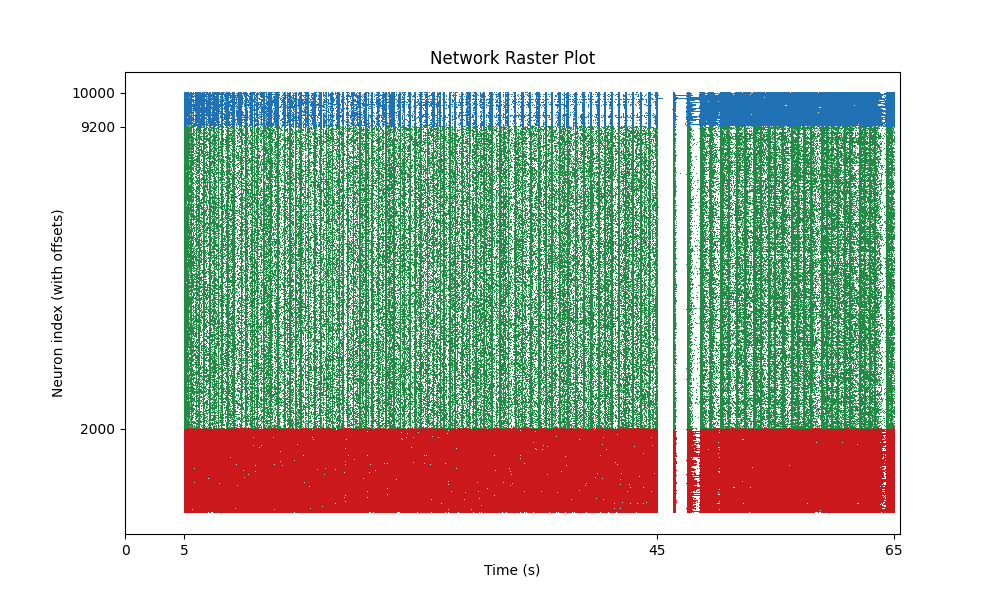

In [8]:
fig = network_raster_plot_h5(pop1 = data['spikes']['FS'], 
                    pop2 = data['spikes']['RS'], 
                    pop3 = data['spikes']['IMP'],
                    N_pop1 = data['metadata']['num_FS_neurons'],
                    N_pop2 = data['metadata']['num_RS_neurons'],
                    N_pop3 = data['metadata']['num_IMP_neurons'],
                    x_lim = [0,65.5])

figs.append(fig)

WARNING    /home/ilaria/.local/lib/python3.8/site-packages/brian2/units/fundamentalunits.py:1036: UserWarning: Unknown ufunc 'clip' in __array_prepare__
  warn("Unknown ufunc '%s' in __array_prepare__" % uf.__name__)
 [py.warnings]
WARNING    /home/ilaria/.local/lib/python3.8/site-packages/brian2/units/fundamentalunits.py:1071: UserWarning: Unknown ufunc 'clip' in __array_wrap__
  warn("Unknown ufunc '%s' in __array_wrap__" % uf.__name__)
 [py.warnings]


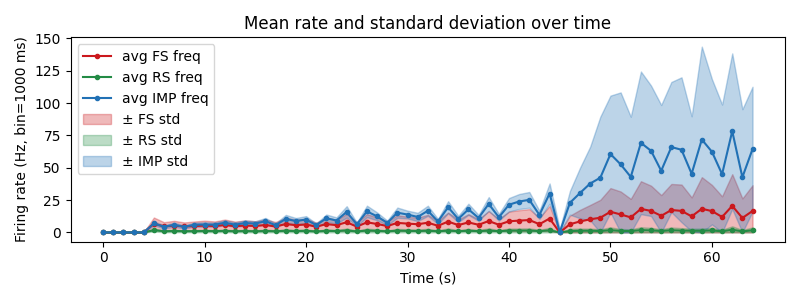

In [9]:
fig, time_bins, mean_rate_FS, mean_rate_RS, mean_rate_IMP = plotting_pop_freq_and_std_h5(sim_duration = data['metadata']['sim_duration'] * b2.second, 
                              pop1 = data['spikes']['FS'], 
                              pop2 = data['spikes']['RS'], 
                              pop3 = data['spikes']['IMP'],
                              N_pop1 = data['metadata']['num_FS_neurons'],
                              N_pop2 = data['metadata']['num_RS_neurons'],
                              N_pop3 = data['metadata']['num_IMP_neurons'],
                              bin_size = 1000 * b2.ms,
                              title = 'Mean rate and standard deviation over time',
                              fig_size=(8,3))
figs.append(fig)

In [10]:
pops = ['FS','RS','IMP']

In [11]:
meta, ictal, interictal, synchro = load_ictal_interictal_synchro_h5(os.path.join(simulation_folder, folder_name, "ictal_interictal_synchro_IMP_cr_Z0_-50_tau_r_1.h5"))

In [12]:
time_bins=np.arange(0,meta['sim_duration'],0.1)

In [13]:
def plot_synchrony_STTCs_h5(sync_FS, sync_RS, sync_IMP, 
                          time_bins, split_time=45, fig_size=None):

    if fig_size == None:
        fig = plt.figure(figsize=(8,6))
    else:
        fig = plt.figure(figsize = fig_size)

    plt.plot(time_bins, sync_FS, color=color['FS'], alpha=0.8, label='FS')
    plt.plot(time_bins, sync_RS, color=color['RS'], alpha=0.8, label='RS')
    plt.plot(time_bins, sync_IMP, color=color['IMP'], alpha=0.8,label='IMP')
    plt.axvline(split_time, color='black', linestyle='--')
    plt.title("Synchrony over time (STTC)")
    plt.ylabel("STTC Correlation Index")
    plt.ylim(-0.1, 1.1) 
    plt.legend()

    return fig

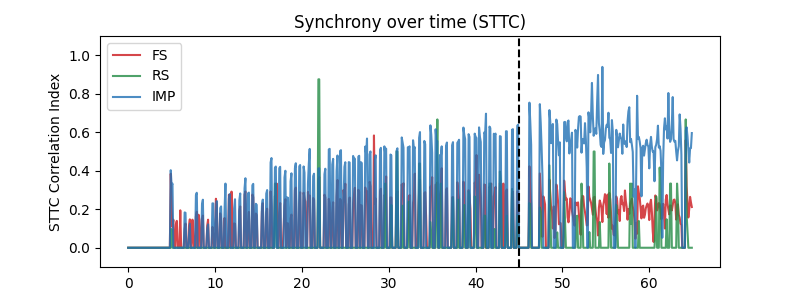

In [14]:
fig = plot_synchrony_STTCs_h5(synchro['FS'], synchro['RS'], synchro['IMP'], 
                         time_bins, split_time=45, fig_size=(8,3))
figs.append(fig)

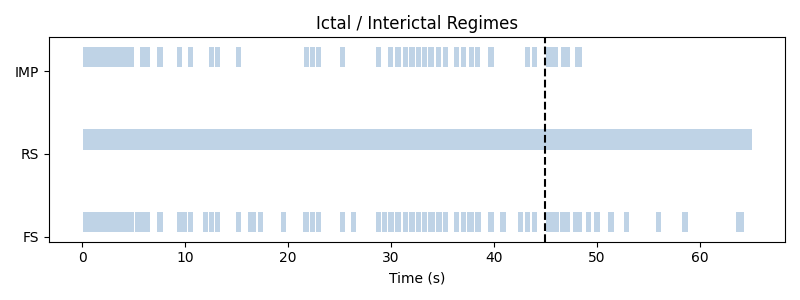

In [15]:
fig=plot_regime_timeline_h5(ictal, interictal, pops, split_time=45, fig_size=(8,3))
figs.append(fig)

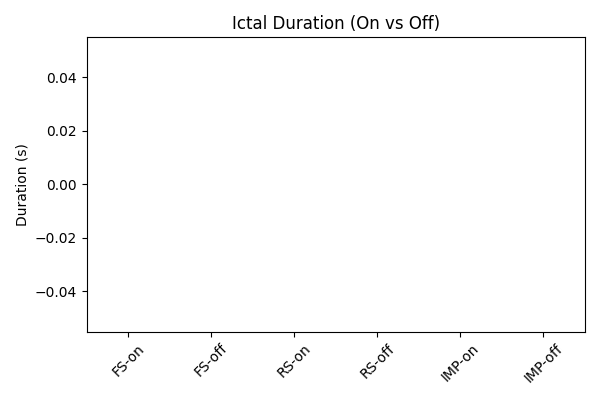

In [16]:
fig = plot_ictal_regime_duration_h5(ictal, pops, split_time=45)
figs.append(fig)

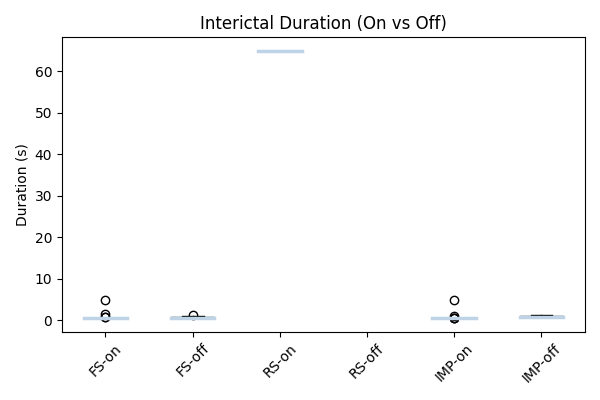

In [17]:
fig = plot_interictal_regime_duration_h5(interictal, pops, split_time=45)
figs.append(fig)

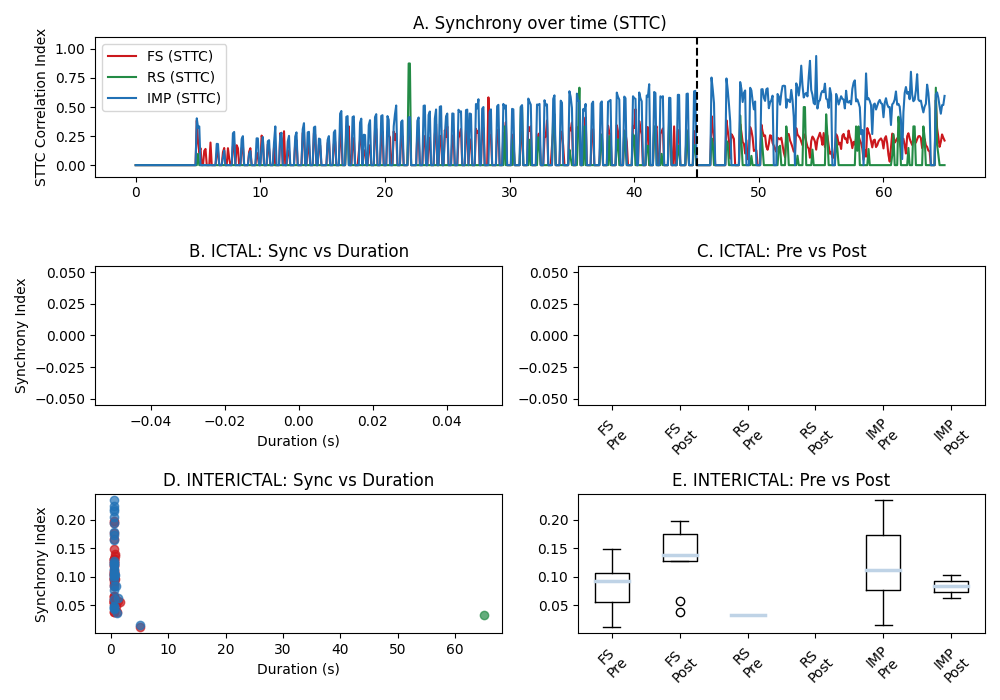

In [18]:
fig = plot_synchrony_panels_h5(pops, ictal, interictal, 
                               synchro['FS'], synchro['RS'], synchro['IMP'], 
                               time_bins, split_time=45)
figs.append(fig)

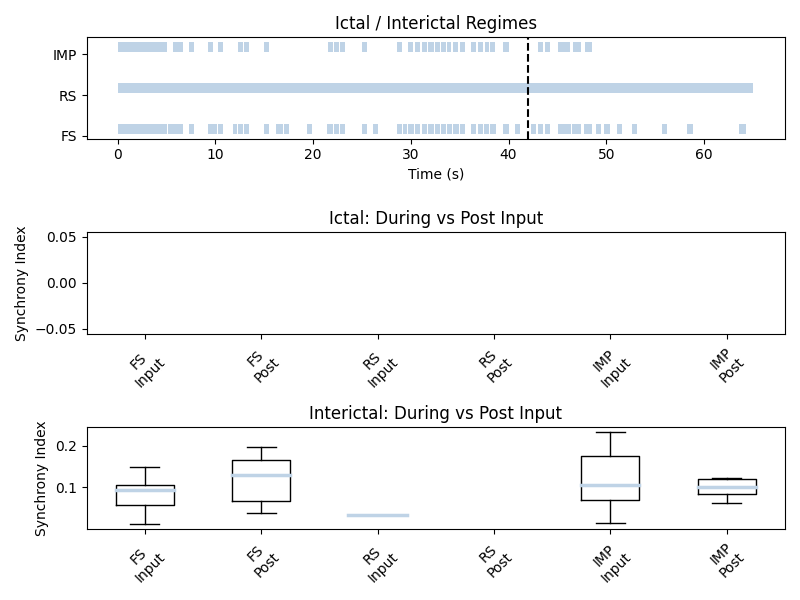

In [19]:
fig = plot_timeline_and_boxplots_h5(
    pops, ictal, interictal,
    synchro['FS'], synchro['RS'], synchro['IMP'],
    time_bins,
    split_time=42,
    fig_size=(8, 6)
)
figs.append(fig)

In [20]:
save_figs(fig_path, fig_name, figs)